# Sales and Profit Analysis

1. What is the trend of sales and profit over time?
2. What regions and markets contribute to the most profits?
3. Which cities and states are the most profitable?
4. Which products are the most popular?
5. What is the sales and profit distribution across different markets?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [13]:
data = pd.read_csv(r"C:\Users\kavin\Downloads\Super_International_Market.csv", encoding = 'latin1')

In [6]:
df = data.copy() # Backup

# Data Exploration

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2/5/2013,5/2/2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,17-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,28-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,11/5/2013,5/11/2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [8]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51285,29002,IN-2014-62366,19-06-2014,19-06-2014,Same Day,KE-16420,Katrina Edelman,Corporate,Kure,Hiroshima,...,OFF-FA-10000746,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,0.01,Medium
51286,35398,US-2014-102288,20-06-2014,20-06-2014,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,Houston,Texas,...,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100,0.01,Medium
51287,40470,US-2013-155768,12/2/2013,2/12/2013,Same Day,LB-16795,Laurel Beltran,Home Office,Oxnard,California,...,OFF-EN-10001219,Office Supplies,Envelopes,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",22.920,3,0.0,11.2308,0.01,High
51288,9596,MX-2012-140767,18-02-2012,18-02-2012,Standard Class,RB-19795,Ross Baird,Home Office,Valinhos,São Paulo,...,OFF-BI-10000806,Office Supplies,Binders,"Acco Index Tab, Economy",13.440,2,0.0,2.4000,0.00,Medium
51289,6147,MX-2012-134460,22-05-2012,22-05-2012,Second Class,MC-18100,Mick Crebagga,Consumer,Tipitapa,Managua,...,OFF-PA-10004155,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.380,3,0.0,1.8000,0.00,High


In [10]:
df.shape

(51290, 24)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [14]:
df.describe(include = 'all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
count,51290.00000,51290,51290,51290,51290,51290,51290,51290,51290,51290,...,51290,51290,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290
unique,NaN,25035,1430,1430,4,1590,795,3,3636,1094,...,10292,3,17,3788,NaN,NaN,NaN,NaN,NaN,4
top,NaN,CA-2014-100111,18-06-2014,18-06-2014,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,...,OFF-AR-10003651,Office Supplies,Binders,Staples,NaN,NaN,NaN,NaN,NaN,Medium
freq,NaN,14,135,135,30775,97,108,26518,915,2001,...,35,31273,6152,227,NaN,NaN,NaN,NaN,NaN,29433
mean,25645.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,246.490581,3.476545,0.142908,28.610982,26.375915,NaN
std,14806.29199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,487.565361,2.278766,0.212280,174.340972,57.296804,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000,0.000000,NaN
25%,12823.25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,30.758625,2.000000,0.000000,0.000000,2.610000,NaN
50%,25645.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,85.053000,3.000000,0.000000,9.240000,7.790000,NaN
75%,38467.75000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,251.053200,5.000000,0.200000,36.810000,24.450000,NaN


In [15]:
df.dtypes

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
City               object
State              object
Country            object
Postal Code       float64
Market             object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority     object
dtype: object

In [17]:
float_cols = df[['Postal Code', 'Sales', 'Discount', 'Profit', 'Shipping Cost']]
float_cols.head()

,Postal Code,Sales,Discount,Profit,Shipping Cost
0,10024.0,2309.650,0.0,762.1845,933.57
1,NaN,3709.395,0.1,-288.7650,923.63
2,NaN,5175.171,0.1,919.9710,915.49
3,NaN,2892.510,0.1,-96.5400,910.16
4,NaN,2832.960,0.0,311.5200,903.04


In [18]:
other_types = df[['Row ID', 'Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country' ]]
other_types.head()

,Row ID,Order ID,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country
0,32298,CA-2012-124891,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States
1,26341,IN-2013-77878,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia
2,25330,IN-2013-71249,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia
3,13524,ES-2013-1579342,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany
4,47221,SG-2013-4320,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal


# Data Cleaning

In [19]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [22]:
date = df[['Order Date', 'Ship Date']]
date.head()

,Order Date,Ship Date
0,31-07-2012,31-07-2012
1,2/5/2013,5/2/2013
2,17-10-2013,17-10-2013
3,28-01-2013,28-01-2013
4,11/5/2013,5/11/2013


In [141]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors= 'coerce')
df['Ship Date'] = pd.to_datetime(df['Order Date'], errors = 'coerce')

df.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode               category
Customer ID               object
Customer Name             object
Segment                 category
City                      object
State                     object
Country                 category
Postal Code              float64
Market                    object
Region                  category
Product ID                object
Category                category
Sub-Category            category
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority          category
dtype: object

In [142]:
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [143]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [28]:
df['Ship Mode'] = df['Ship Mode'].astype('category')
df['Segment'] = df['Segment'].astype('category')
df['Country'] = df['Country'].astype('category')
df['Region'] = df['Region'].astype('category')
df['Category'] = df['Category'].astype('category')
df['Sub-Category'] = df['Sub-Category'].astype('category')
df['Order Priority'] = df['Order Priority'].astype('category')

In [29]:
df.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode               category
Customer ID               object
Customer Name             object
Segment                 category
City                      object
State                     object
Country                 category
Postal Code              float64
Market                    object
Region                  category
Product ID                object
Category                category
Sub-Category            category
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority          category
dtype: object

In [30]:
df.duplicated().sum()

np.int64(0)

In [144]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date        20067
Ship Date         20067
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code           0
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [33]:
df.nunique()

Row ID            51290
Order ID          25035
Order Date          865
Ship Date           865
Ship Mode             4
Customer ID        1590
Customer Name       795
Segment               3
City               3636
State              1094
Country             147
Postal Code         631
Market                7
Region               13
Product ID        10292
Category              3
Sub-Category         17
Product Name       3788
Sales             22995
Quantity             14
Discount             27
Profit            24575
Shipping Cost     10037
Order Priority        4
dtype: int64

In [34]:
df.head(50)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.6500,7,0.00,762.1845,933.57,Critical
1,26341,IN-2013-77878,NaT,NaT,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.3950,9,0.10,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-17,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.1710,9,0.10,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-28,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.5100,5,0.10,-96.5400,910.16,Medium
4,47221,SG-2013-4320,NaT,NaT,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.9600,8,0.00,311.5200,903.04,Critical
5,22732,IN-2013-42360,2013-06-28,2013-06-28,Second Class,JM-15655,Jim Mitchum,Corporate,Sydney,New South Wales,...,TEC-PH-10000030,Technology,Phones,"Samsung Smart Phone, with Caller ID",2862.6750,5,0.10,763.2750,897.35,Critical
6,30570,IN-2011-81826,NaT,NaT,First Class,TS-21340,Toby Swindell,Consumer,Porirua,Wellington,...,FUR-CH-10004050,Furniture,Chairs,"Novimex Executive Leather Armchair, Adjustable",1822.0800,4,0.00,564.8400,894.77,Critical
7,31192,IN-2012-86369,2012-04-14,2012-04-14,Standard Class,MB-18085,Mick Brown,Consumer,Hamilton,Waikato,...,FUR-TA-10002958,Furniture,Tables,"Chromcraft Conference Table, Fully Assembled",5244.8400,6,0.00,996.4800,878.38,High
8,40155,CA-2014-135909,2014-10-14,2014-10-14,Standard Class,JW-15220,Jane Waco,Corporate,Sacramento,California,...,OFF-BI-10003527,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,5083.9600,5,0.20,1906.4850,867.69,Low
9,40936,CA-2012-116638,2012-01-28,2012-01-28,Second Class,JH-15985,Joseph Holt,Consumer,Concord,North Carolina,...,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.6440,13,0.40,-1862.3124,865.74,Critical


In [36]:
df[df['Order Date'].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
1,26341,IN-2013-77878,NaT,NaT,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
4,47221,SG-2013-4320,NaT,NaT,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical
6,30570,IN-2011-81826,NaT,NaT,First Class,TS-21340,Toby Swindell,Consumer,Porirua,Wellington,...,FUR-CH-10004050,Furniture,Chairs,"Novimex Executive Leather Armchair, Adjustable",1822.080,4,0.0,564.8400,894.77,Critical
10,34577,CA-2011-102988,NaT,NaT,Second Class,GM-14695,Greg Maxwell,Corporate,Alexandria,Virginia,...,OFF-SU-10002881,Office Supplies,Supplies,Martin Yale Chadless Opener Electric Letter Op...,4164.050,5,0.0,83.2810,846.54,High
14,27704,IN-2013-73951,NaT,NaT,Second Class,PF-19120,Peter Fuller,Consumer,Mudanjiang,Heilongjiang,...,OFF-AP-10003500,Office Supplies,Appliances,"KitchenAid Microwave, White",3701.520,12,0.0,1036.0800,804.54,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51276,31558,US-2014-155299,NaT,NaT,Standard Class,Dl-13600,Dorris liebe,Corporate,Pasadena,Texas,...,OFF-AP-10002203,Office Supplies,Appliances,Eureka Disposable Bags for Sanitaire Vibra Gro...,1.624,2,0.8,-4.4660,0.02,Medium
51278,43818,NI-2011-4700,NaT,NaT,Second Class,PO-8865,Patrick O'Donnell,Consumer,Lagos,Lagos,...,OFF-STA-10001791,Office Supplies,Art,"Stanley Highlighters, Water Color",5.364,1,0.7,-6.4560,0.02,High
51281,6039,MX-2014-169530,NaT,NaT,First Class,HG-15025,Hunter Glantz,Consumer,Bragança Paulista,São Paulo,...,OFF-PA-10002418,Office Supplies,Paper,"Green Bar Message Books, Multicolor",84.000,5,0.0,9.2000,0.02,High
51284,24175,IN-2014-57662,NaT,NaT,Standard Class,DB-13270,Deborah Brumfield,Home Office,Townsville,Queensland,...,OFF-BI-10002424,Office Supplies,Binders,"Avery Binder, Economy",58.050,5,0.1,19.9500,0.01,Medium


In [38]:
postal_code_mode = df['Postal Code'].mode()[0]
df['Postal Code'] = df['Postal Code'].fillna(postal_code_mode)

In [139]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date        20067
Ship Date         20067
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code           0
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [140]:
data.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [42]:
negative_profit_count = (df['Profit'] <0).sum()
negative_profit_count

np.int64(12544)

In [43]:
mean_profit = df['Profit'].mean()
mean_profit

np.float64(28.61098247767596)

In [45]:
mean_profit = df[df['Profit']>0]['Profit'].mean()
mean_profit

np.float64(62.71609451651873)

In [46]:
# Replacing negative profit values with calculated mean

df['Profit'] = df['Profit'].apply(lambda x:mean_profit if x <0 else x)

In [47]:
print("Negative values in 'Profit' have been replaced with the mean of non-negative profits.")
print(df['Profit'].head(5))

Negative values in 'Profit' have been replaced with the mean of non-negative profits.
0    762.184500
1     62.716095
2    919.971000
3     62.716095
4    311.520000
Name: Profit, dtype: float64


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      31223 non-null  datetime64[ns]
 3   Ship Date       31223 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  category      
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  category      
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  category      
 11  Postal Code     51290 non-null  float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  category      
 14  Product ID      51290 non-null  object        
 15  Ca

# Segmenting the data

In [51]:
seg_data = df[['Customer ID', 'Customer Name', 'Category', 'Product Name', 'Sub-Category', 'Sales', 'Profit', 'Quantity', 'Discount', 'Order Date', 'City', 'State', 'Region', 'Market', 'Order Priority']]

In [52]:
seg_data

,Customer ID,Customer Name,Category,Product Name,Sub-Category,Sales,Profit,Quantity,Discount,Order Date,City,State,Region,Market,Order Priority
0,RH-19495,Rick Hansen,Technology,Plantronics CS510 - Over-the-Head monaural Wir...,Accessories,2309.650,762.184500,7,0.0,2012-07-31,New York City,New York,East,US,Critical
1,JR-16210,Justin Ritter,Furniture,"Novimex Executive Leather Armchair, Black",Chairs,3709.395,62.716095,9,0.1,NaT,Wollongong,New South Wales,Oceania,APAC,Critical
2,CR-12730,Craig Reiter,Technology,"Nokia Smart Phone, with Caller ID",Phones,5175.171,919.971000,9,0.1,2013-10-17,Brisbane,Queensland,Oceania,APAC,Medium
3,KM-16375,Katherine Murray,Technology,"Motorola Smart Phone, Cordless",Phones,2892.510,62.716095,5,0.1,2013-01-28,Berlin,Berlin,Central,EU,Medium
4,RH-9495,Rick Hansen,Technology,"Sharp Wireless Fax, High-Speed",Copiers,2832.960,311.520000,8,0.0,NaT,Dakar,Dakar,Africa,Africa,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,KE-16420,Katrina Edelman,Office Supplies,"Advantus Thumb Tacks, 12 Pack",Fasteners,65.100,4.500000,5,0.0,2014-06-19,Kure,Hiroshima,North Asia,APAC,Medium
51286,ZC-21910,Zuschuss Carroll,Office Supplies,Hoover Replacement Belt for Commercial Guardsm...,Appliances,0.444,62.716095,1,0.8,2014-06-20,Houston,Texas,Central,US,Medium
51287,LB-16795,Laurel Beltran,Office Supplies,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",Envelopes,22.920,11.230800,3,0.0,NaT,Oxnard,California,West,US,High
51288,RB-19795,Ross Baird,Office Supplies,"Acco Index Tab, Economy",Binders,13.440,2.400000,2,0.0,2012-02-18,Valinhos,São Paulo,South,LATAM,Medium


# 1. What is the trend of sales and profit over time?

In [54]:
seg_data.loc[:, 'Order Date'] = pd.to_datetime(seg_data['Order Date'])
seg_data.loc[:, 'Year'] = seg_data['Order Date'].dt.year
sales_profit_trend = seg_data.groupby('Year')[['Sales', 'Profit']].sum()
sales_profit_trend

,Sales,Profit
Year,,
2011.0,1.363519e+06,330102.922735
2012.0,1.671012e+06,412551.985961
2013.0,2.064486e+06,518833.232114
2014.0,2.677963e+06,673137.040526


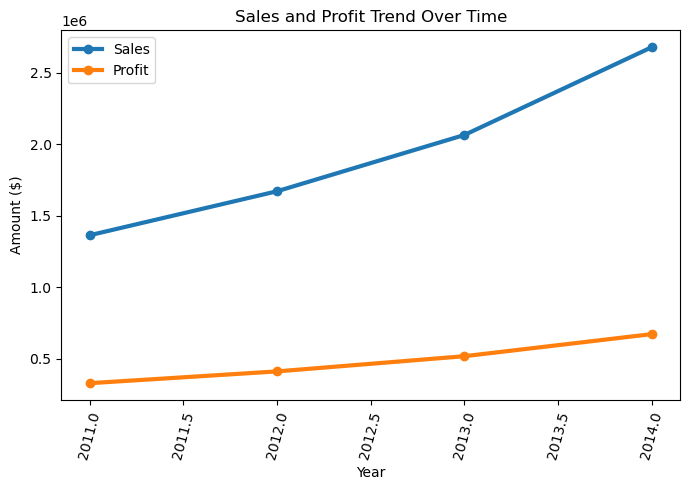

In [65]:
plt.figure(figsize= (7,5))
plt.plot(sales_profit_trend.index, sales_profit_trend['Sales'], label = 'Sales', linewidth = 3, marker = 'o')
plt.plot(sales_profit_trend.index, sales_profit_trend['Profit'], label = 'Profit', linewidth = 3, marker = 'o')
plt.title('Sales and Profit Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Amount ($)')
plt.legend(loc = 'upper left')
plt.xticks(rotation = 75)
plt.tight_layout()
plt.show()

This line charts shows an uptrend in both sales and profit. Sales growth shows that the revenue of the company is increasing while the profit trend shows an improved profitability. Overal this tells us that the business is performing great. 

# 2. Which regions and markets contribute the most to sales and profit

In [69]:
region_market_sales_profit = seg_data.groupby(['Region', 'Market'], observed=False)[['Sales', 'Profit']].sum()
top_region_sales = region_market_sales_profit.sort_values(by='Sales', ascending=False)
top_market_sales = region_market_sales_profit.sort_values(by='Profit', ascending=False)

In [77]:
top_region_sales[['Sales']].head(20)

,,Sales
Region,Market,
Central,EU,1.720553e+06
Oceania,APAC,1.100185e+06
Southeast Asia,APAC,8.844232e+05
North Asia,APAC,8.483098e+05
EMEA,EMEA,8.061613e+05
Africa,Africa,7.837732e+05
Central Asia,APAC,7.528266e+05
West,US,7.254578e+05
East,US,6.787812e+05


In [78]:
top_market_sales[['Profit']].head(20)

,,Profit
Region,Market,
Central,EU,381873.894197
EMEA,EMEA,267685.931794
Oceania,APAC,242478.640093
Africa,Africa,242344.241352
Southeast Asia,APAC,211934.503054
North Asia,APAC,204993.478888
Central Asia,APAC,179169.731803
East,US,175795.387768
South,LATAM,171125.905938


In [84]:
top_region_sales = region_market_sales_profit.sort_values(by='Sales', ascending=False).head()
top_market_profit = region_market_sales_profit.sort_values(by='Profit', ascending=False).head()

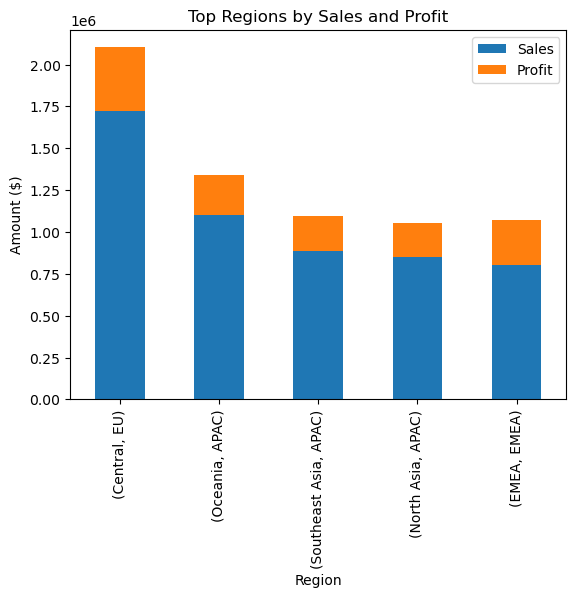

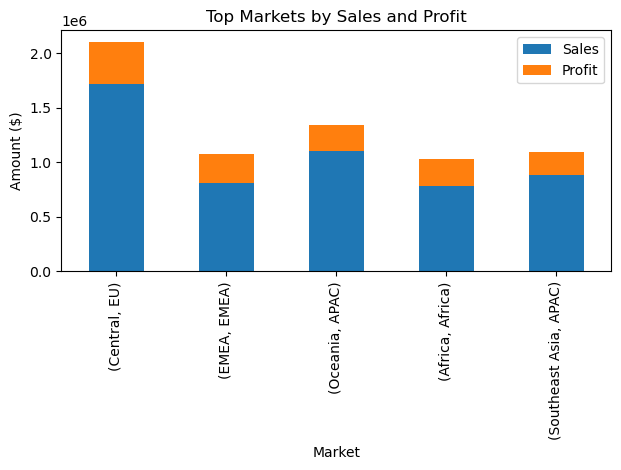

In [95]:
top_region_sales[['Sales', 'Profit']].plot(kind = 'bar', stacked=True)
plt.title('Top Regions by Sales and Profit')
plt.xlabel('Region')
plt.ylabel('Amount ($)')

top_market_profit[['Sales', 'Profit']].plot(kind='bar', stacked=True)
plt.title('Top Markets by Sales and Profit')
plt.xlabel('Market')
plt.ylabel('Amount ($)')

plt.tight_layout()
plt.show()

These charts show the regions and markets with the highest contributions to sales and profits. 
I used a stacked bar chart to compare the sales and profit across different regions and markets. 
The blue color represents the sales, and the orange color preresent the profit. 

# What cities and states are the most profitable

In [97]:
city_state_profit = seg_data.groupby(['City', 'State'])['Profit'].sum().reset_index()

In [98]:
top_city_state_profit = city_state_profit.sort_values(by='Profit', ascending =False).head()

In [99]:
top_city_state_profit

,City,State,Profit
2402,New York City,New York,68511.650081
2006,Los Angeles,California,33931.583397
3085,Seattle,Washington,30544.725112
2096,Manila,National Capital,26464.556571
1580,Jakarta,Jakarta,25636.489265


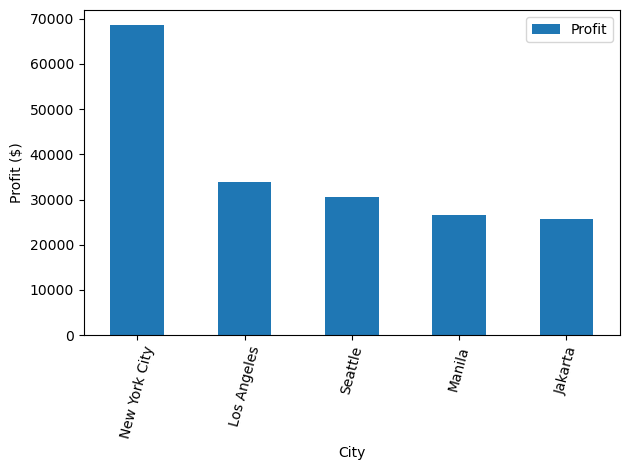

In [103]:
top_city_state_profit.plot(kind = 'bar', x = 'City', y = 'Profit')
plt.xlabel('City')
plt.ylabel('Profit ($)')
plt.xticks(rotation = 75)
plt.tight_layout()
plt.show()

# 4. Which products are the most popular (highest quantity sold)?

In [105]:
highest_quantity_products = seg_data.groupby('Product Name')['Quantity'].sum().reset_index()

In [106]:
top_products = highest_quantity_products.sort_values(by='Quantity', ascending=False).head()

In [107]:
top_products

,Product Name,Quantity
3275,Staples,876
894,"Cardinal Index Tab, Clear",337
1210,"Eldon File Cart, Single Width",321
2840,"Rogers File Cart, Single Width",262
3070,"Sanford Pencil Sharpener, Water Color",259


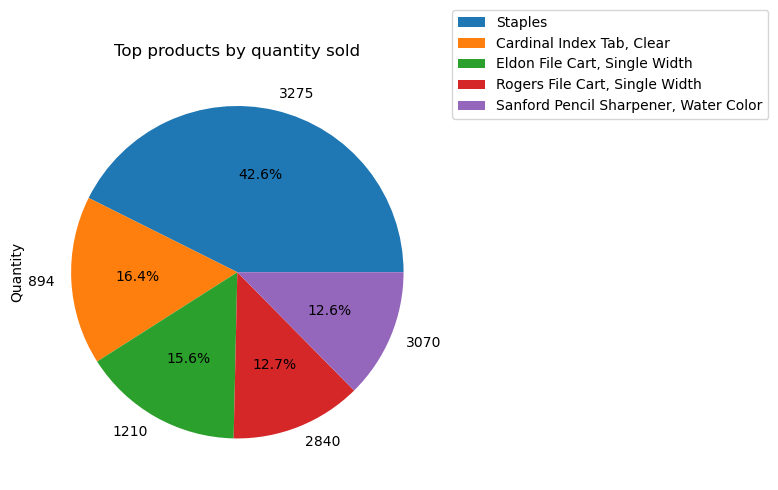

In [138]:
plt.figure(figsize = (24,5))
top_products['Quantity'].plot(kind='pie', autopct='%.1f%%')
plt.title('Top products by quantity sold')
plt.legend(top_products['Product Name'], loc='center left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

This pie charts shows the top products based on the quantity sold. As we can see staples are the most sold product
followed by Cardinal Index Tab, Eldon File art, and Regoers File Cart. 

# 5. What is the sales and profit distribution across different markets?

In [128]:
market_sales_profit = seg_data.groupby('Market')[['Sales', 'Profit']].sum().reset_index()

In [129]:
market_sales_profit

,Market,Sales,Profit
0,APAC,3.585744e+06,838576.353838
1,Africa,7.837732e+05,242344.241352
2,Canada,6.692817e+04,17817.390000
3,EMEA,8.061613e+05,267685.931794
4,EU,2.938089e+06,691851.425186
5,LATAM,2.164605e+06,556668.674206
6,US,2.297201e+06,559870.120240


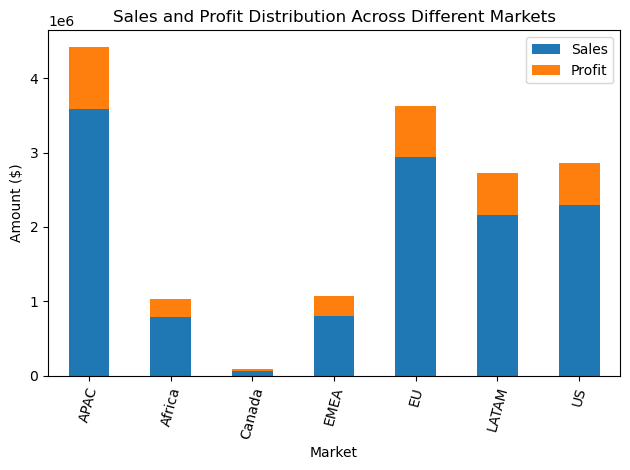

In [134]:
market_sales_profit.set_index('Market')[['Sales', 'Profit']].plot(kind='bar', stacked=True)
plt.xlabel("Market")
plt.ylabel("Amount ($)")
plt.xticks(rotation = 75)
plt.title("Sales and Profit Distribution Across Different Markets")
plt.tight_layout()
plt.show()

This chart shows the distribution across different markets sing a stacked bar chart. The sales is shown by blue color while the profit is shown by orange color. As we can see APAC market has the highest sales followed by EU and US markets. 